### Create SMET Forcing Files from HRRR-AK Data: Point Simulation PPSA2

Notebook contents 
* SNOWPACK takes an SMET file, so let's create that for point simulations

created by Cassie Lumbrazo\
last updated: Feb 2025\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd

from zoneinfo import ZoneInfo
from pathlib import Path

In [2]:
pwd

'/home/cassie/python/repos/snow_model_forcing/sites/ppsa2'

So actually this python library exists: PySMET: https://snowpat.slf.ch/indexsmet/

but I am going to create my own script for now... 

## Load the HRRR Dataset, 

In [8]:
input_file = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2025_utm_site_ppsa2.nc"
ds = xr.open_dataset(input_file)
ds.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work
ds

<xarray.Dataset> Size: 2MB
Dimensions:       (time: 8760)
Coordinates:
  * time          (time) datetime64[ns] 70kB 2024-10-01 ... 2025-09-30T21:00:00
    y             float64 8B ...
    x             float64 8B ...
    spatial_ref   int64 8B 0
Data variables: (12/27)
    gust          (time) float64 70kB ...
    pressure      (time) float64 70kB ...
    orog          (time) float64 70kB ...
    temp_surface  (time) float64 70kB ...
    swe           (time) float64 70kB ...
    snowdepth     (time) float64 70kB ...
    ...            ...
    hcc           (time) float64 70kB ...
    swrad         (time) float64 70kB ...
    lwrad         (time) float64 70kB ...
    suswrf        (time) float64 70kB ...
    sulwrf        (time) float64 70kB ...
    wind          (time) float64 70kB ...
Attributes: (12/13)
    long_name:       Wind speed (gust)
    units:           m s**-1
    GRIB_shortName:  gust
    GRIB_name:       Wind speed (gust)
    GRIB_cfName:     unknown
    GRIB_cfVarName:  gust
    ...              ...
    typeOfLevel:     surface
    site_name:       ppsa2
    original_lat:    58.262
    original_lon:    -134.517
    utm_x:           528340.7656649345
    utm_y:           6457981.62778889

In [9]:
# print the first few timestamps to see the time resolution
print(ds.time.values[:10])

['2024-10-01T00:00:00.000000000' '2024-10-01T00:00:00.000000000'
 '2024-10-01T00:00:00.000000000' '2024-10-01T03:00:00.000000000'
 '2024-10-01T03:00:00.000000000' '2024-10-01T03:00:00.000000000'
 '2024-10-01T06:00:00.000000000' '2024-10-01T06:00:00.000000000'
 '2024-10-01T06:00:00.000000000' '2024-10-01T09:00:00.000000000']


In [10]:
# check the crs 
print(ds.rio.crs)

EPSG:32608


# The Workflow Below, 

HRRR (NetCDF / xarray)\
   → your Python script\
   → SMET (ASCII)\
   → SNOWPACK


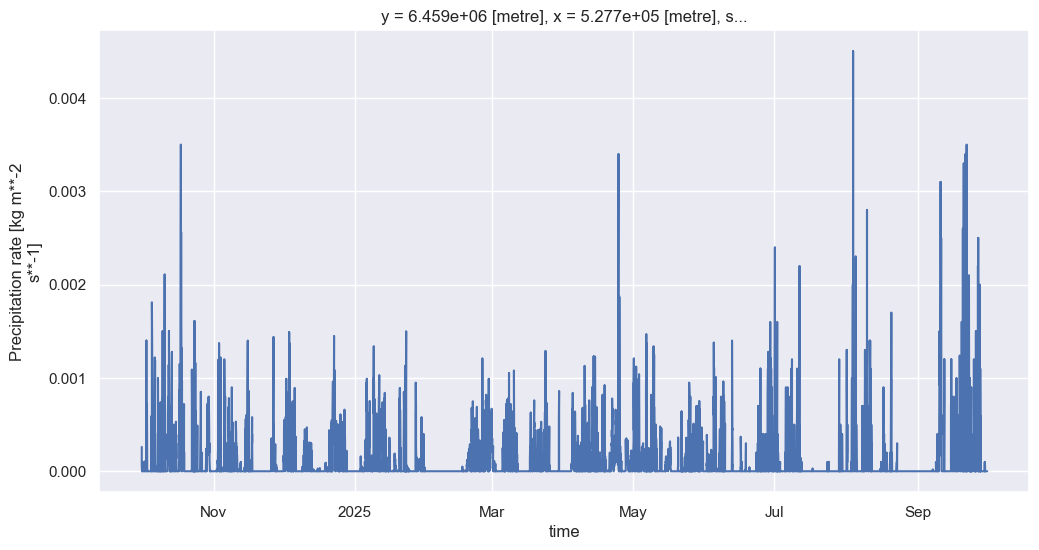

In [21]:
# ds['temp'].plot() # 2-m surface temperature in K, need in K
# ds['rh'].plot() # 2-m relative humidity in %, need in fraction (0-1)
# ds['10u'].plot() # 10-m u wind component in m/s, need in m/s
# ds['10v'].plot() # 10-m v wind component in m/s, need in m/s
# ds['swrad'].plot() # surface downward shortwave radiation in W/m2, need in W/m2
# ds['lwrad'].plot() # surface downward longwave radiation in W/m2, need in W/m2
ds['precip_rate'].plot() # precipitation rate in kg/m2s, need in mm per timestep
# ds['pressure'].plot() # surface pressure in Pa, need in Pa

### Precipitation Variables from HRRR-AK

`ds.precip_rate` is the precipiation rate\
units: kg/m²/s\
range: 0–0.0035

In [22]:
ds.precip_rate.attrs

{'long_name': 'Precipitation rate',
 'units': 'kg m**-2 s**-1',
 'GRIB_shortName': 'prate',
 'GRIB_name': 'Precipitation rate',
 'GRIB_cfName': 'unknown',
 'GRIB_cfVarName': 'prate',
 'level': np.int32(0),
 'typeOfLevel': 'surface',
 'grid_mapping': 'spatial_ref'}

#### MeteoIO Variable Names 
| MeteoIO name | Meaning                      | Required?            | Expected units              |
| ------------ | ---------------------------- | -------------------- | --------------------------- |
| `TA`         | Air temperature              | yes                  | °K                          |
| `RH`         | Relative humidity            | yes                  | fraction (0-1)              |
| `VW`         | Wind speed                   | yes                  | m s⁻¹                       |
| `DW`         | Wind direction               | optional             | degrees (0–360, from North) |
| `ISWR`       | Incoming shortwave radiation | strongly recommended | W m⁻²                       |
| `ILWR`       | Incoming longwave radiation  | strongly recommended | W m⁻²                       |
| `PSUM`       | Precipitation (increment)    | yes                  | mm (per timestep)           |
| `P`          | Air pressure                 | optional             | Pa                          |


HRRR to MeteIO Variable Mapping 

In [13]:
# --- Unit expectations (SMET / MeteoIO) ---
# TA    : Kelvin
# RH    : fraction (0–1)
# VW    : m s-1
# DW    : degrees (meteorological)
# ISWR : W m-2
# ILWR : W m-2
# PSUM : mm per timestep
# P     : Pa

# Create SMET File

In [26]:
from pathlib import Path
from pyproj import Transformer

This version dealing with the timestepping, and precipiation units over that timestep

In [27]:
lat_ppsa2, lon_ppsa2, elevation_ppsa2 = 58.26200, -134.51700, 670
# lat_tram, lon_tram, elevation_tram = 58.2971, -134.386, 529
# lat_heen, lon_heen, elevation_heen = 58.69652, -134.86448, 548
# lat_tkg4, lon_tkg4, elevation_tkg4 = 58.63447,-134.23708, 1120

In [28]:
# =========================
# USER SETTINGS
# =========================
OUTFILE = Path("/home/cassie/python/models/run_snowpack/sites/ppsa2/input/hrrrak_ppsa2_WY2025.smet")

STATION_ID = "hrrrak_ppsa2_WY2025"
STATION_NAME = "HRRR-AK Powder Patch Point Forcing"
LAT = lat_ppsa2
LON = lon_ppsa2
ELEV = elevation_ppsa2
EPSG = 32608
TZ = 0
NODATA = -999

# -------------------------
# SIMULATION TIMESTEP
# -------------------------
# Default: 1 hour
TIMESTEP = "1h"      # pandas-style string: "1h", "30min", "15min" H is deprecated, use lowercase
TIMESTEP_SECONDS = pd.to_timedelta(TIMESTEP).total_seconds()

# =========================
# COORDINATE TRANSFORM
# =========================
transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32608",
    always_xy=True
)

EASTING, NORTHING = transformer.transform(LON, LAT)

# =========================
# BUILD DATAFRAME
# =========================
time = pd.to_datetime(ds.time.values)
df = pd.DataFrame(index=time)

# Base variables
df["TA"] = ds.temp.values
df["RH"] = (ds.rh.values / 100.0)
df["ISWR"] = ds.swrad.values
df["ILWR"] = ds.lwrad.values
df["PS"] = ds.pressure.values

# ---- Wind speed & direction ----
u = ds['10u'].values
v = ds['10v'].values

df["VW"] = np.sqrt(u**2 + v**2)
df["DW"] = (270.0 - np.degrees(np.arctan2(v, u))) % 360.0

# ---- Precipitation conversion ----
# precip_rate: kg/m²/s → mm per timestep
df["PSUM"] = ds.precip_rate.values * TIMESTEP_SECONDS

# =========================
# RESAMPLE TO MODEL TIMESTEP
# =========================
# For energy variables → mean
mean_vars = ["TA", "RH", "VW", "DW", "ISWR", "ILWR", "PS"]

# For precipitation → sum
sum_vars = ["PSUM"]

df_mean = df[mean_vars].resample(TIMESTEP).mean()
df_sum = df[sum_vars].resample(TIMESTEP).sum()

df = pd.concat([df_mean, df_sum], axis=1)

# Replace missing values
df = df.fillna(NODATA)

# =========================
# WRITE SMET
# =========================
with open(OUTFILE, "w") as f:
    f.write("SMET 1.1 ASCII\n")
    f.write("[HEADER]\n")

    f.write(f"station_id       = {STATION_ID}\n")
    f.write(f"station_name     = {STATION_NAME}\n")
    f.write(f"latitude         = {LAT:.6f}\n")
    f.write(f"longitude        = {LON:.6f}\n")
    f.write(f"easting          = {EASTING:.3f}\n")
    f.write(f"northing         = {NORTHING:.3f}\n")
    f.write(f"epsg             = {EPSG}\n")
    f.write(f"altitude         = {ELEV}\n")
    f.write(f"nodata           = {NODATA}\n")
    f.write(f"tz               = {TZ}\n")

    f.write("source           = HRRR point extraction\n")
    f.write("fields           = timestamp TA RH VW DW ISWR ILWR PSUM PS\n")
    f.write("[DATA]\n")

    for t, row in df.iterrows():
        f.write(
            f"{t.strftime('%Y-%m-%dT%H:%M')} "
            f"{row.TA:8.2f} {row.RH:6.3f} "
            f"{row.VW:6.2f} {row.DW:6.1f} "
            f"{row.ISWR:8.1f} {row.ILWR:8.1f} "
            f"{row.PSUM:7.3f} {row.PS:8.1f}\n"
        )

There is an issue with the timeseries data which is only every 3 hours, so I need to go back to the hrrr download script to see what's wrong...